In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('./data/raw/shopping.csv')

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [4]:
df["Payment Method"].value_counts()
df["Shipping Type"].value_counts()

Shipping Type
Standard          2162
2-Day Shipping    1173
Next Day Air       284
Express            279
Store Pickup         2
Name: count, dtype: int64

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


In [6]:

df['Age'] = df['Age'].fillna(0).astype('int64')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [7]:


top_products = df.groupby("Gender")['Item Purchased'].value_counts()

top_products_female = top_products["Female"][:5]

In [8]:
top_products_male = top_products["Male"][:5]

Text(0, 0.5, 'Quantity')

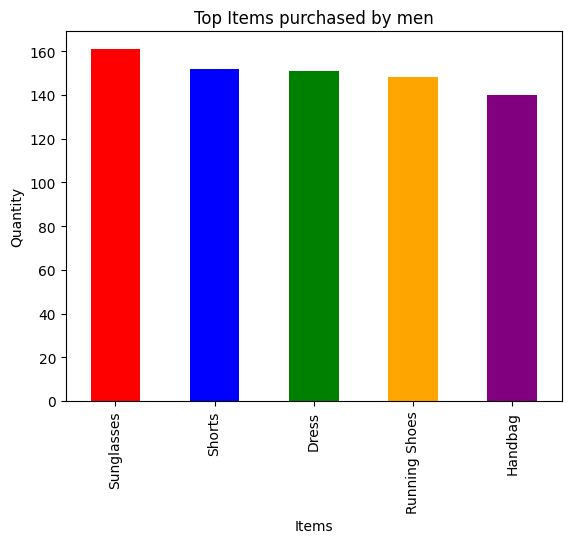

In [9]:
my_colors = ['red', 'blue', 'green', 'orange', 'purple']
top_products_male.plot.bar(color=my_colors)

plt.title("Top Items purchased by men")
plt.xlabel("Items")
plt.ylabel("Quantity")

Text(0, 0.5, 'Quantity')

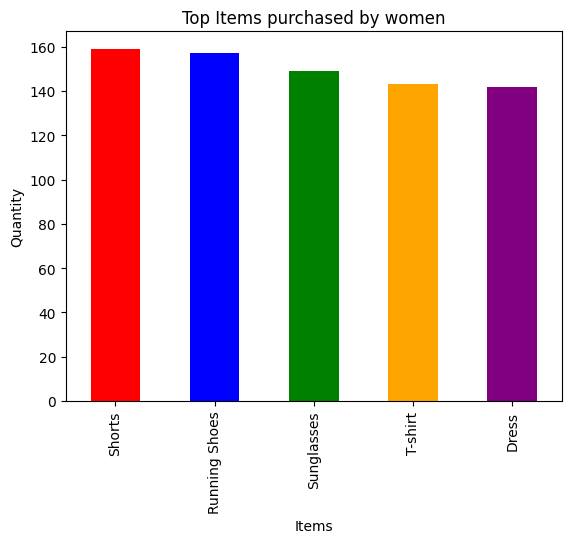

In [10]:
my_colors = ['red', 'blue', 'green', 'orange', 'purple']
top_products_female.plot.bar(color=my_colors)

plt.title("Top Items purchased by women")
plt.xlabel("Items")
plt.ylabel("Quantity")

In [20]:
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].__round__(2)



markets_purchasing_power = df.groupby("Location")['Purchase Amount (USD)'].agg(["sum"]).sort_values(by="sum", ascending=False)[:10]
markets_purchasing_power

markets_highest_average = df.groupby("Location")['Purchase Amount (USD)'].agg(["mean"]).sort_values(by="mean", ascending=False)[:10]
markets_highest_average


,mean
Location,
Indiana,43.471690
Hawaii,41.779434
Iowa,41.728769
Missouri,40.847500
Massachusetts,40.517059
South Carolina,40.432500
Florida,40.347213
West Virginia,40.096282
Nebraska,39.946625


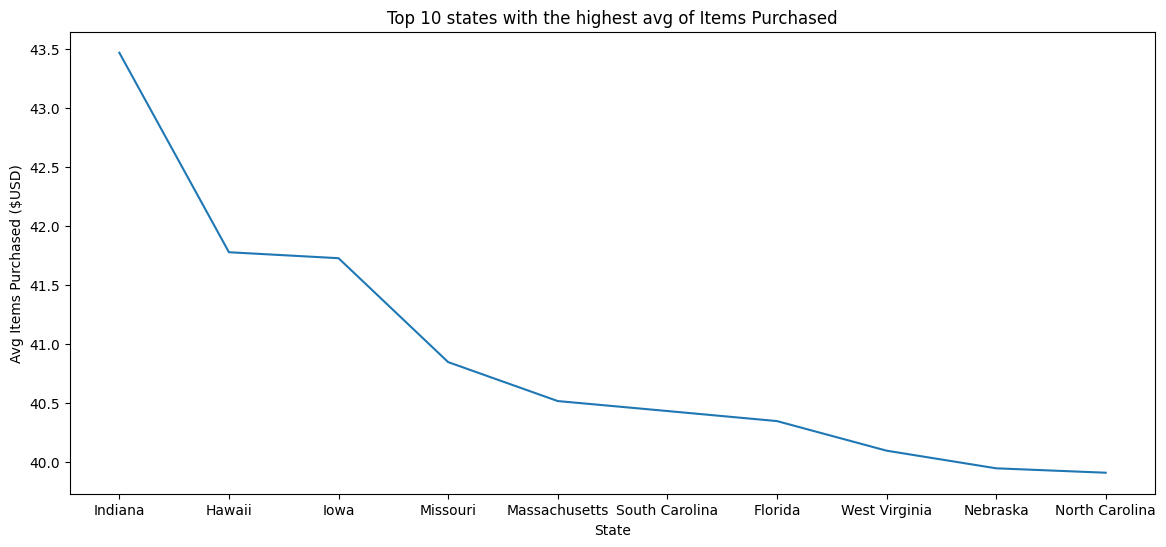

In [21]:

plt.figure(figsize=(14,6))
plt.plot(markets_highest_average['mean'])

plt.title("Top 10 states with the highest avg of Items Purchased")
plt.ylabel("Avg Items Purchased ($USD)")
plt.xlabel("State")
plt.show()



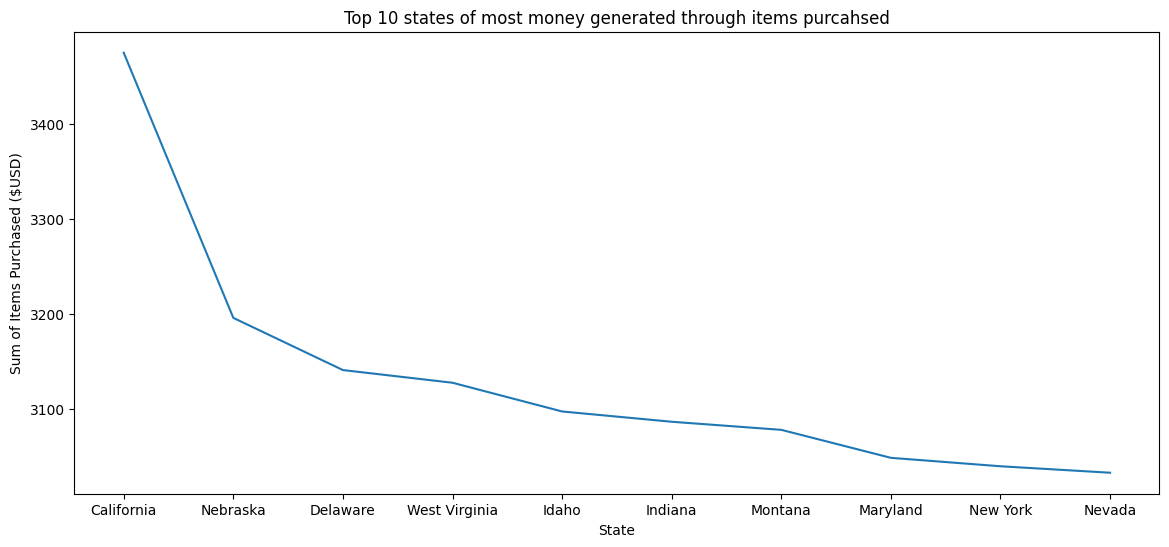

In [18]:
plt.figure(figsize=(14,6))
plt.plot(markets_purchasing_power['sum'])

plt.title("Top 10 states of most money generated through items purcahsed")
plt.ylabel("Sum of Items Purchased ($USD)")
plt.xlabel("State")
plt.show()

In [14]:
df['Purchase Amount (USD)'].min()

lower_bucket_range = df[(df["Purchase Amount (USD)"] > 10.00) & (df["Purchase Amount (USD)"] < 24.99)]
middle_bucket_range = df[(df["Purchase Amount (USD)"] > 25.00) & (df["Purchase Amount (USD)"] < 43.99)]
high_bucket_range = df[(df["Purchase Amount (USD)"] > 44.00) & (df["Purchase Amount (USD)"] < 58.99)]
exceptional_bucket_range = df[(df["Purchase Amount (USD)"] > 59.00) & (df["Purchase Amount (USD)"] < 73.99)]

total_items_purchased_high = len(high_bucket_range['Item Purchased'])
total_items_purchased_middle = len(middle_bucket_range['Item Purchased'])
total_items_purchased_lower = len(lower_bucket_range['Item Purchased'])
total_items_purchased_exceptional = len(exceptional_bucket_range['Item Purchased'])

labels = ["low", "mid", "high", "exceptional"]

values = [total_items_purchased_lower, total_items_purchased_middle, total_items_purchased_high, total_items_purchased_exceptional]





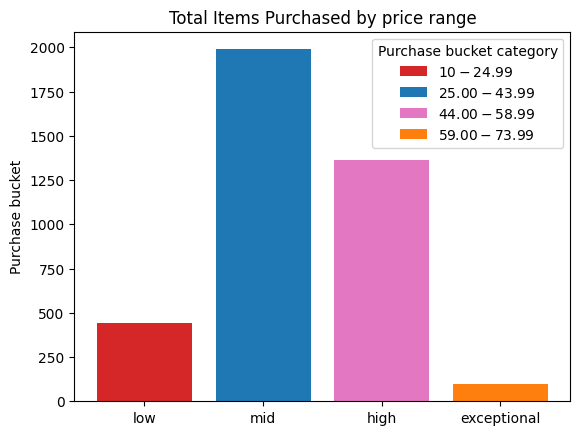

In [15]:
fig, ax = plt.subplots()

bar_labels = ['$10 - $24.99', '$25.00 - $43.99', '$44.00 - $58.99', '$59.00 - $73.99']
bar_colors = ['tab:red', 'tab:blue', 'tab:pink', 'tab:orange']

ax.bar(labels, values, label=bar_labels, color=bar_colors)

ax.set_ylabel('Purchase bucket')
ax.set_title('Total Items Purchased by price range')
ax.legend(title='Purchase bucket category')

plt.show()